## Modelo clasificatorio de cancer de mama LOGIT

Fuente: Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B.

Dataset:
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Es recomendado leer el dataset para comprender mejor el contexto de la información antes de trabajar en el código.

In [29]:
# Modelo Logit.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

In [30]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target', 'target_name'],
      dtype='object')

In [31]:
# Cambiando variable a que 1 sea maligno y 0 benigno
df["target"] = 1 - df["target"]

df[['mean radius', 'target', 'target_name']]

,mean radius,target,target_name
0,17.99,1,malignant
1,20.57,1,malignant
2,19.69,1,malignant
3,11.42,1,malignant
4,20.29,1,malignant
...,...,...,...
564,21.56,1,malignant
565,20.13,1,malignant
566,16.60,1,malignant
567,20.60,1,malignant


In [32]:
# Construir variables x y y
x = df['mean radius'] # x =df['cualquier variable que me guste']
y = df['target']

# ajustar modelo logit con sm (statsmodel)
X = sm.add_constant(x)  # Agrega intercepto que es un B0 (y = B0 + B1*X1)
model = sm.Logit(y, X).fit() #ajusta el modelo (entrena)
# Summarize model
summary = model.summary2().as_text()

print(summary)

Optimization terminated successfully.
         Current function value: 0.289992
         Iterations 8
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: target           Pseudo R-squared: 0.561     
Date:               2026-09-06 12:38 AIC:              334.0108  
No. Observations:   569              BIC:              342.6986  
Df Model:           1                Log-Likelihood:   -165.01   
Df Residuals:       567              LL-Null:          -375.72   
Converged:          1.0000           LLR p-value:      1.1923e-93
No. Iterations:     8.0000           Scale:            1.0000    
-----------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-----------------------------------------------------------------
const         -15.2459   1.3247 -11.5086 0.0000 -17.8423 -12.6494
mean radius     1.0336   0.0931  11.1002 0.0000   0.8511   1.2161


En modelos logit la R2 funciona diferente. El rango es 0-1 pero puede tener valores negativos. Un valor mayor a 0.2 se considera un buen modelo. La tabla reporta un valor de pseudo-r2 de 0.56, por lo tanto podemos usar este modelo para entender la relación entre el tamaño de un tumor (mean radius) y si es benigno o maligno.

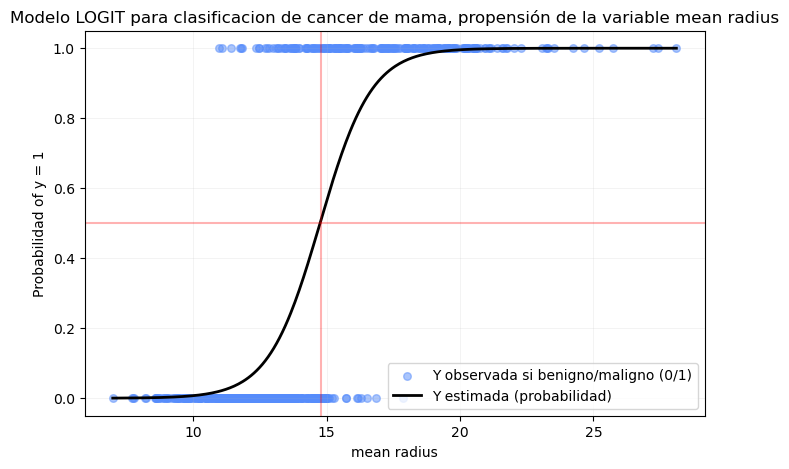

In [33]:

# Creando gráfica de probabilidades
x_grid = np.linspace(x.min(), x.max(), 400)
X_grid = sm.add_constant(x_grid)
pred_prob = model.predict(X_grid) # Estimamos y (maligno o benign, usando X)

# Construyendo figura
# Tamaño de la figura
plt.figure(figsize=(8, 5))

#Dispersión
plt.scatter(x, y, alpha=0.5, label="Y observada si benigno/maligno (0/1)", s=30)
plt.plot(x_grid, pred_prob, linewidth=2, label="Y estimada (probabilidad)", color = 'black')

# Ejes y etiquetas
plt.xlabel("mean radius")
plt.ylabel("Probabilidad of y = 1")
plt.title("Modelo LOGIT para clasificacion de cancer de mama, propensión de la variable mean radius")

#plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)

# linea horizontal
plt.axhline(y=0.5, color='r', linestyle='-', alpha = 0.3)
plt.axvline(x=14.8, color='r', linestyle='-', alpha = 0.3)

In [34]:
# Clasificación
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Test y train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)


# Construimos un modelo para el train
X_train = sm.add_constant(x_train)
#model = sm.Logit(y_train, X_train).fit(disp=False)

# Prediccion
X_test = sm.add_constant(x_test)
y_pred_prob = model.predict(X_test)

# Convierte la predicción en etiqueta
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

In [35]:
# Show confusion matrix values
print("matriz de confusion\n",cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_class, target_names=cancer.target_names))

matriz de confusion
 [[72  2]
 [ 7 33]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.91      0.97      0.94        74
      benign       0.94      0.82      0.88        40

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114

